# IMPORT LIBRARIES

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

#LOAD DATASET

In [ ]:
df = pd.read_csv("/content/mobile_price_dataset.csv")
df.head()

,Brand,Model,Price_USD,RAM_GB,Storage_GB,Battery_mAh,Screen_Size_Inch,Camera_MP,OS,Release_Year
0,Samsung,Galaxy S21,799,8,128,4000,6.20,64,Android,2021
1,Apple,iPhone 13,999,4,128,3240,6.10,12,iOS,2021
2,Xiaomi,Redmi Note 11,199,6,128,5000,6.43,50,Android,2022
3,Realme,Realme 9 Pro,299,8,128,5000,6.60,64,Android,2022
4,OnePlus,OnePlus 9,729,8,128,4500,6.55,48,Android,2021


#DATA UNDERSTANDING

In [ ]:
print("SHAPE:", df.shape)
print("\nCOLUMNS:\n", df.columns)

SHAPE: (15, 10)

COLUMNS:
 Index(['Brand', 'Model', 'Price_USD', 'RAM_GB', 'Storage_GB', 'Battery_mAh',
       'Screen_Size_Inch', 'Camera_MP', 'OS', 'Release_Year'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             15 non-null     object 
 1   Model             15 non-null     object 
 2   Price_USD         15 non-null     int64  
 3   RAM_GB            15 non-null     int64  
 4   Storage_GB        15 non-null     int64  
 5   Battery_mAh       15 non-null     int64  
 6   Screen_Size_Inch  15 non-null     float64
 7   Camera_MP         15 non-null     int64  
 8   OS                15 non-null     object 
 9   Release_Year      15 non-null     int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 1.3+ KB


In [ ]:
df.describe()

,Price_USD,RAM_GB,Storage_GB,Battery_mAh,Screen_Size_Inch,Camera_MP,Release_Year
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,441.000000,6.266667,123.733333,4464.333333,6.472667,49.400000,2021.066667
std,277.004384,1.667619,45.038819,706.391400,0.204955,24.523458,0.593617
min,199.000000,4.000000,64.000000,2815.000000,6.100000,12.000000,2020.000000
25%,234.000000,5.000000,128.000000,4100.000000,6.415000,48.000000,2021.000000
50%,299.000000,6.000000,128.000000,4500.000000,6.510000,48.000000,2021.000000
75%,614.000000,8.000000,128.000000,5000.000000,6.600000,64.000000,2021.000000
max,999.000000,8.000000,256.000000,5160.000000,6.800000,108.000000,2022.000000


# MISSING + DUPLICATES CHECK

In [ ]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Missing values:
 Brand               0
Model               0
Price_USD           0
RAM_GB              0
Storage_GB          0
Battery_mAh         0
Screen_Size_Inch    0
Camera_MP           0
OS                  0
Release_Year        0
dtype: int64

Duplicates: 0


#DATA CLEANING

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = ((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)).any(axis=1)
df_cleaned = df[~outlier_mask].copy()

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after outlier removal: {df_cleaned.shape}")
print("\nFirst 5 rows of cleaned DataFrame:")
print(df_cleaned.head())

Original DataFrame shape: (15, 10)
DataFrame shape after outlier removal: (5, 10)

First 5 rows of cleaned DataFrame:
      Brand       Model  Price_USD  RAM_GB  Storage_GB  Battery_mAh  \
0   Samsung  Galaxy S21        799       8         128         4000   
4   OnePlus   OnePlus 9        729       8         128         4500   
6      Vivo    Vivo V21        399       8         128         4000   
10    Tecno    Camon 18        219       6         128         5000   
12  Samsung  Galaxy A52        499       6         128         4500   

    Screen_Size_Inch  Camera_MP       OS  Release_Year  
0               6.20         64  Android          2021  
4               6.55         48  Android          2021  
6               6.44         64  Android          2021  
10              6.80         48  Android          2021  
12              6.50         64  Android          2021  


#EXPLORATORY DATA ANALYSIS (GRAPHS )

# Price Distribution

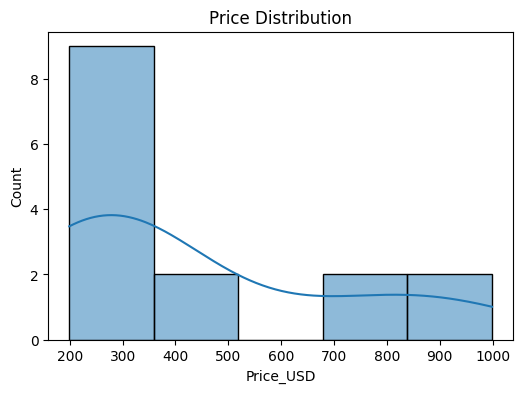

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Price_USD'], kde=True)
plt.title("Price Distribution")
plt.show()

# Battery vs Price

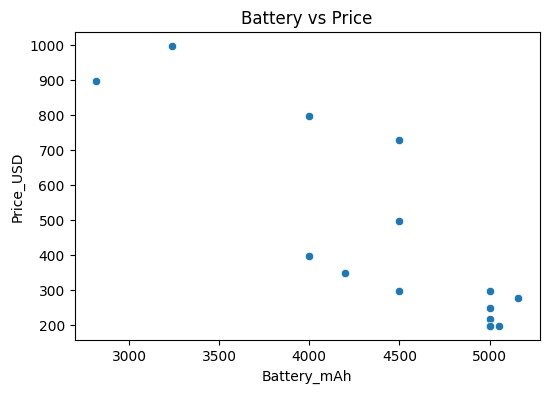

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Battery_mAh'], y=df['Price_USD'])
plt.title("Battery vs Price")
plt.show()

#RAM vs Price

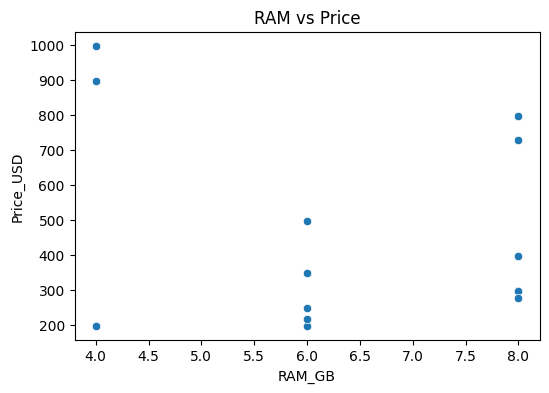

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['RAM_GB'], y=df['Price_USD'])
plt.title("RAM vs Price")
plt.show()

# Storage vs Price

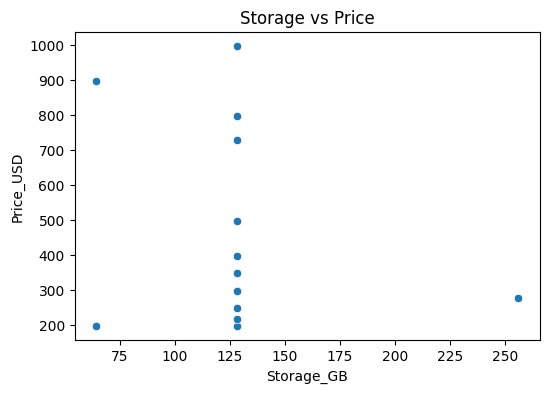

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Storage_GB'], y=df['Price_USD'])
plt.title("Storage vs Price")
plt.show()

# Camera vs Price

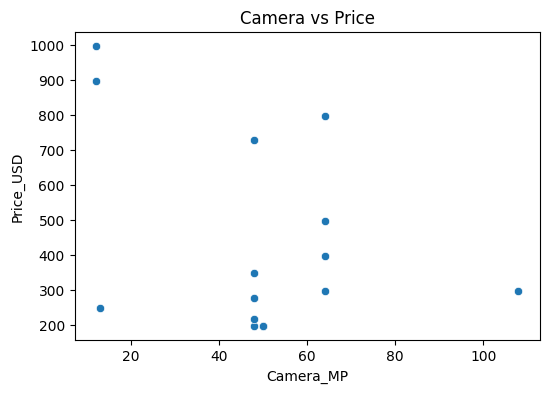

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Camera_MP'], y=df['Price_USD'])
plt.title("Camera vs Price")
plt.show()

# Correlation Heatmap

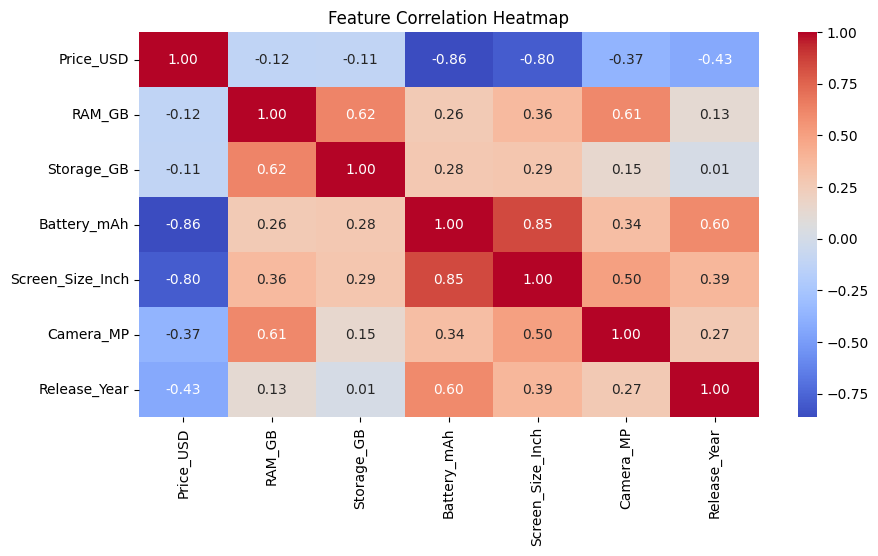

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# FEATURE ENGINEERING


#Convert categorical columns (Brand, OS)

In [ ]:
df = pd.get_dummies(df, columns=['Brand', 'OS'], drop_first=True)
df.head()

,Model,Price_USD,RAM_GB,Storage_GB,Battery_mAh,Screen_Size_Inch,Camera_MP,Release_Year,Brand_Huawei,Brand_Infinix,Brand_Nokia,Brand_OnePlus,Brand_Oppo,Brand_Realme,Brand_Samsung,Brand_Tecno,Brand_Vivo,Brand_Xiaomi,OS_iOS
0,Galaxy S21,799,8,128,4000,6.20,64,2021,False,False,False,False,False,False,True,False,False,False,False
1,iPhone 13,999,4,128,3240,6.10,12,2021,False,False,False,False,False,False,False,False,False,False,True
2,Redmi Note 11,199,6,128,5000,6.43,50,2022,False,False,False,False,False,False,False,False,False,True,False
3,Realme 9 Pro,299,8,128,5000,6.60,64,2022,False,False,False,False,False,True,False,False,False,False,False
4,OnePlus 9,729,8,128,4500,6.55,48,2021,False,False,False,True,False,False,False,False,False,False,False


# SPLIT FEATURES & TARGET

In [ ]:
X = df.drop(['Price_USD', 'Model'], axis=1)
y = df['Price_USD']

# TRAIN TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#MACHINE LEARNING MODELS

#Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression R2 Score:", r2_score(y_test, pred_lr))

Linear Regression R2 Score: 0.8242818489248244


# Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree R2 Score:", r2_score(y_test, pred_dt))

Decision Tree R2 Score: 0.564516129032258


# Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest R2 Score:", r2_score(y_test, pred_rf))

Random Forest R2 Score: 0.395008


# MODEL EVALUATION

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
print("Linear Regression R2:", r2_score(y_test, pred_lr))
print("Decision Tree R2:", r2_score(y_test, pred_dt))
print("Random Forest R2:", r2_score(y_test, pred_rf))

Linear Regression R2: 0.8242818489248244
Decision Tree R2: 0.564516129032258
Random Forest R2: 0.395008


#MODEL COMPARISSION GRAPH

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


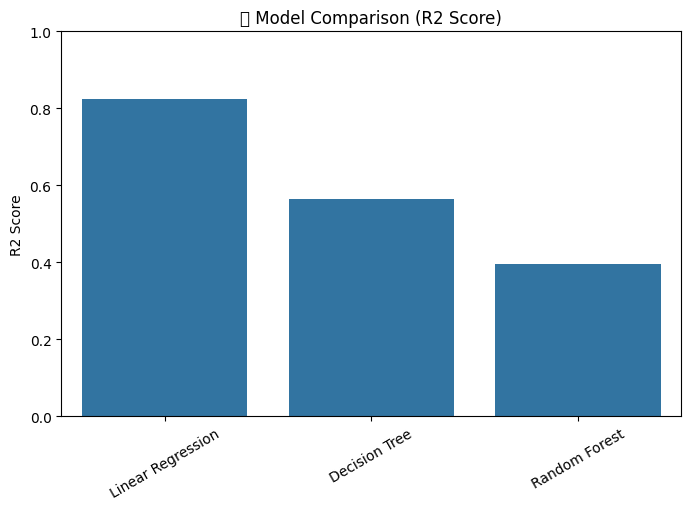

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Model names
models = ['Linear Regression', 'Decision Tree', 'Random Forest']

# R2 scores (yahan apne variables use karo)
scores = [
    r2_score(y_test, pred_lr),
    r2_score(y_test, pred_dt),
    r2_score(y_test, pred_rf)
]

# Graph
plt.figure(figsize=(8,5))
sns.barplot(x=models, y=scores)

plt.title("📊 Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.ylim(0, 1)

plt.xticks(rotation=30)

plt.show()

#ERROR COMPARISON

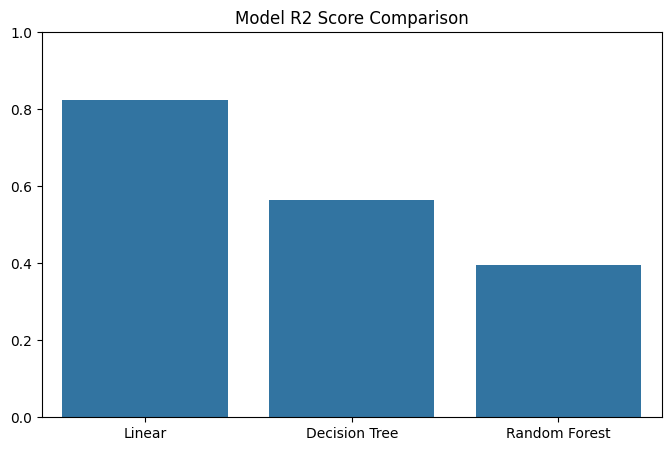

In [ ]:
models = ['Linear', 'Decision Tree', 'Random Forest']
scores = [
    r2_score(y_test, pred_lr),
    r2_score(y_test, pred_dt),
    r2_score(y_test, pred_rf)
]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=scores)
plt.title("Model R2 Score Comparison")
plt.ylim(0,1)
plt.show()

#BEST MODEL

In [ ]:
best_score = max(scores)
best_model = models[scores.index(best_score)]

print("Best Model:", best_model)
print("Best Score:", best_score)

Best Model: Linear
Best Score: 0.8242818489248244


# ACTUAL VS PREDICTED (BEST MODEL)

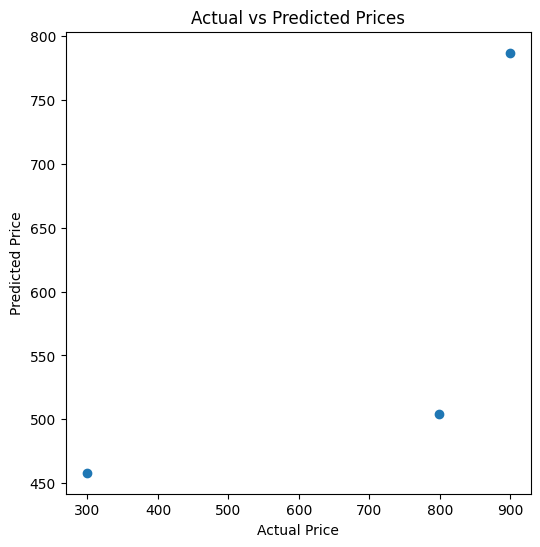

In [ ]:
best_pred = pred_rf  # Random Forest best assumed

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()